In [4]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, f1_score, accuracy_score
)
import matplotlib.pyplot as plt

# ── Load observations ──
observations = pd.read_pickle('/kaggle/input/datasets/maanav0114/harps-n-dataset/observations.pkl')
print(f"Total observations: {len(observations)}")
print(f"Stars: {observations['star_name'].nunique()}")

Total observations: 235567
Stars: 2187


## Compute per-star summary statistics

Same 16 physical features as `baseline.ipynb` plus 2 activity-variance flags (18 total). No observational proxies.

In [5]:
def compute_star_features(group):
    """Compute summary statistics for one star from its observation sequence."""
    features = {}

    # -- RV statistics --
    features['rv_std'] = group['rv_centered'].std()
    features['rv_range'] = group['rv_centered'].max() - group['rv_centered'].min()
    features['rv_mean_abs_dev'] = (group['rv_centered'] - group['rv_centered'].median()).abs().mean()
    features['rv_skew'] = group['rv_centered'].skew()
    features['rv_kurtosis'] = group['rv_centered'].kurtosis()

    # -- RV error statistics --
    features['rv_err_mean'] = group['rv_err'].mean()
    features['rv_err_std'] = group['rv_err'].std()

    # -- Activity indicator statistics --
    features['rhkp_std'] = group['RHKp'].std()
    features['rhkp_range'] = group['RHKp'].max() - group['RHKp'].min()
    features['rhkp_mean'] = group['RHKp'].mean()
    features['halpha_std'] = group['Halpha'].std()
    features['halpha_range'] = group['Halpha'].max() - group['Halpha'].min()
    features['halpha_mean'] = group['Halpha'].mean()

    # -- RV-activity correlations --
    features['rv_rhkp_corr'] = group['rv_centered'].corr(group['RHKp'])
    features['rv_halpha_corr'] = group['rv_centered'].corr(group['Halpha'])
    features['rhkp_halpha_corr'] = group['RHKp'].corr(group['Halpha'])

    # -- Binary variance flags: 1 if indicator had variance, 0 if constant (corr NaN -> aliased to 0) --
    features['rhkp_has_variance'] = 1 if group['RHKp'].std() > 0 else 0
    features['halpha_has_variance'] = 1 if group['Halpha'].std() > 0 else 0

    # -- Label --
    features['has_exoplanets'] = group['has_exoplanets'].iloc[0]

    return pd.Series(features)

star_features = observations.groupby('star_name').apply(compute_star_features, include_groups=False).reset_index()
star_features = star_features.fillna(0)
star_features['has_exoplanets'] = star_features['has_exoplanets'].astype(int)

physical_features = [
    'rv_std', 'rv_range', 'rv_mean_abs_dev', 'rv_skew', 'rv_kurtosis',
    'rv_err_mean', 'rv_err_std',
    'rhkp_std', 'rhkp_range', 'rhkp_mean',
    'halpha_std', 'halpha_range', 'halpha_mean',
    'rv_rhkp_corr', 'rv_halpha_corr', 'rhkp_halpha_corr',
    'rhkp_has_variance', 'halpha_has_variance'
]

print(f"Stars: {len(star_features)}")
print(f"Positive: {star_features['has_exoplanets'].sum()}")
print(f"Negative: {(star_features['has_exoplanets'] == 0).sum()}")
print(f"Features ({len(physical_features)}): {physical_features}")

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Stars: 2187
Positive: 413
Negative: 1774
Features (18): ['rv_std', 'rv_range', 'rv_mean_abs_dev', 'rv_skew', 'rv_kurtosis', 'rv_err_mean', 'rv_err_std', 'rhkp_std', 'rhkp_range', 'rhkp_mean', 'halpha_std', 'halpha_range', 'halpha_mean', 'rv_rhkp_corr', 'rv_halpha_corr', 'rhkp_halpha_corr', 'rhkp_has_variance', 'halpha_has_variance']


## Multi-Seed Evaluation

For each seed in `range(42, 48)`:
1. Build a stratified 60/20/20 split (same two-stage logic as `split.py`, but with `random_state=seed`)
2. No standardization (RF splits are invariant to monotonic feature transforms)
3. Train `RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=seed)`
4. Choose F1-optimal threshold on the validation set
5. Evaluate on the test set: ROC-AUC, PR-AUC, F1, precision, recall, accuracy
6. Record feature importances

After the loop: report per-seed results, mean ± std, and feature importance stability.

In [6]:
SEEDS = list(range(43, 48))

results = {
    'seed': [], 'roc_auc': [], 'pr_auc': [], 'f1': [],
    'precision': [], 'recall': [], 'accuracy': [], 'threshold': [],
    'ci_lo': [], 'ci_hi': [], 'f05': [],
}
importances_per_seed = {}

from split import bootstrap_roc_auc
from sklearn.metrics import f1_score as sk_f1_score, fbeta_score

X_mat = star_features[physical_features].values
y_vec = star_features['has_exoplanets'].values.astype(int)

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"SEED {seed}")
    print(f"{'='*60}")

    # ── 1. Stratified split (two-stage, same as split.py) ──
    idx = np.arange(len(star_features))
    idx_train, idx_temp, y_train_split, y_temp = train_test_split(
        idx, y_vec, test_size=0.4, random_state=seed, stratify=y_vec,
    )
    idx_val, idx_test, y_val_split, y_test_split = train_test_split(
        idx_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp,
    )

    X_train, y_train = X_mat[idx_train], y_vec[idx_train]
    X_val,   y_val   = X_mat[idx_val],   y_vec[idx_val]
    X_test,  y_test  = X_mat[idx_test],  y_vec[idx_test]

    # No standardization: RF splits are invariant to monotonic feature transforms,
    # so (X - mean)/std would not change a single tree split. Omitted for clarity.
    X_train_s, X_val_s, X_test_s = X_train, X_val, X_test

    print(f"Train: {len(X_train_s)} (pos={y_train.sum()}, neg={(1-y_train).sum()})")
    print(f"Val:   {len(X_val_s)} (pos={y_val.sum()}, neg={(1-y_val).sum()})")
    print(f"Test:  {len(X_test_s)} (pos={y_test.sum()}, neg={(1-y_test).sum()})")

    # ── 3. Train RF ──
    rf = RandomForestClassifier(
        n_estimators=500, class_weight='balanced',
        random_state=seed, max_depth=None,
    )
    rf.fit(X_train_s, y_train)

    # ── 4. Threshold on VAL ──
    val_probs = rf.predict_proba(X_val_s)[:, 1]
    val_prec, val_rec, val_thr = precision_recall_curve(y_val, val_probs)
    val_f1 = 2 * val_prec * val_rec / (val_prec + val_rec + 1e-8)
    best_idx = int(np.argmax(val_f1))
    threshold = float(val_thr[best_idx]) if best_idx < len(val_thr) else 0.5
    val_f1_best = sk_f1_score(y_val, (val_probs >= threshold).astype(int), zero_division=0)

    # ── 5. Evaluate on TEST ──
    test_probs = rf.predict_proba(X_test_s)[:, 1]
    roc = roc_auc_score(y_test, test_probs)
    pr  = average_precision_score(y_test, test_probs)

    test_preds = (test_probs >= threshold).astype(int)
    cm = confusion_matrix(y_test, test_preds)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = sk_f1_score(y_test, test_preds, zero_division=0)
    f05       = fbeta_score(y_test, test_preds, beta=0.5, zero_division=0)
    acc       = accuracy_score(y_test, test_preds)

    results['seed'].append(seed)
    results['roc_auc'].append(roc)
    results['pr_auc'].append(pr)
    results['f1'].append(f1)
    results['f05'].append(f05)
    results['precision'].append(precision)
    results['recall'].append(recall)
    results['accuracy'].append(acc)
    results['threshold'].append(threshold)
    importances_per_seed[seed] = rf.feature_importances_

    print(f"ROC-AUC:  {roc:.4f}")
    print(f"PR-AUC:   {pr:.4f}")
    print(f"F1   (val→test, thr={threshold:.4f}): {f1:.4f}  (val F1={val_f1_best:.4f})")
    print(f"F0.5 (val→test, thr={threshold:.4f}): {f05:.4f}")
    print(f"Precision: {precision:.4f}  Recall: {recall:.4f}  Accuracy: {acc:.4f}")
    print(f"Confusion: TP={tp} FP={fp} TN={tn} FN={fn}")

    # Bootstrap 95% CI for ROC-AUC on this seed's test set
    ci_point, ci_lo, ci_hi = bootstrap_roc_auc(y_test, test_probs, n_resamples=200, seed=seed)
    print(f"  Bootstrap 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
    results['ci_lo'].append(ci_lo)
    results['ci_hi'].append(ci_hi)

print(f"\n\n{'='*60}")
print("ALL SEEDS COMPLETE")
print(f"{'='*60}")


SEED 43
Train: 1312 (pos=248, neg=1064)
Val:   437 (pos=82, neg=355)
Test:  438 (pos=83, neg=355)
ROC-AUC:  0.8245
PR-AUC:   0.5956
F1   (val→test, thr=0.2840): 0.5311  (val F1=0.5079)
F0.5 (val→test, thr=0.2840): 0.5120
Precision: 0.5000  Recall: 0.5663  Accuracy: 0.8105
Confusion: TP=47 FP=47 TN=308 FN=36
  Bootstrap 95% CI: [0.7813, 0.8695]

SEED 44
Train: 1312 (pos=248, neg=1064)
Val:   437 (pos=82, neg=355)
Test:  438 (pos=83, neg=355)
ROC-AUC:  0.8449
PR-AUC:   0.5896
F1   (val→test, thr=0.3140): 0.5698  (val F1=0.5765)
F0.5 (val→test, thr=0.3140): 0.5581
Precision: 0.5506  Recall: 0.5904  Accuracy: 0.8311
Confusion: TP=49 FP=40 TN=315 FN=34
  Bootstrap 95% CI: [0.7936, 0.8865]

SEED 45
Train: 1312 (pos=248, neg=1064)
Val:   437 (pos=82, neg=355)
Test:  438 (pos=83, neg=355)
ROC-AUC:  0.8669
PR-AUC:   0.6321
F1   (val→test, thr=0.2740): 0.5581  (val F1=0.5106)
F0.5 (val→test, thr=0.2740): 0.5467
Precision: 0.5393  Recall: 0.5783  Accuracy: 0.8265
Confusion: TP=48 FP=41 TN=314 FN

## Summary: Mean ± Std Across Seeds

In [7]:
results_df = pd.DataFrame(results)
print(results_df[['seed', 'roc_auc', 'ci_lo', 'ci_hi', 'pr_auc', 'f1', 'f05', 'precision', 'recall', 'accuracy', 'threshold']].to_string(index=False))

print(f"\n{'='*60}")
print(f"AGGREGATE STATISTICS (mean ± std, n={len(SEEDS)} seeds)")
print(f"{'='*60}")
for metric in ['roc_auc', 'pr_auc', 'f1', 'f05', 'precision', 'recall', 'accuracy', 'threshold']:
    vals = np.array(results[metric])
    print(f"  {metric:12s}: {vals.mean():.4f} ± {vals.std(ddof=1):.4f}  (min={vals.min():.4f}, max={vals.max():.4f})")
print(f"\n  Bootstrap CIs per seed:")
for i, s in enumerate(SEEDS):
    print(f"    Seed {s}: ROC-AUC {results['roc_auc'][i]:.4f} [{results['ci_lo'][i]:.4f}, {results['ci_hi'][i]:.4f}]")


 seed  roc_auc    ci_lo    ci_hi   pr_auc       f1      f05  precision   recall  accuracy  threshold
   43 0.824470 0.781268 0.869459 0.595586 0.531073 0.511983   0.500000 0.566265  0.810502      0.284
   44 0.844867 0.793594 0.886504 0.589567 0.569767 0.558087   0.550562 0.590361  0.831050      0.314
   45 0.866893 0.827884 0.901110 0.632112 0.558140 0.546697   0.539326 0.578313  0.826484      0.274
   46 0.836433 0.780654 0.882604 0.614769 0.572973 0.539715   0.519608 0.638554  0.819635      0.254
   47 0.830019 0.777570 0.874719 0.580013 0.531915 0.497018   0.476190 0.602410  0.799087      0.256

AGGREGATE STATISTICS (mean ± std, n=5 seeds)
  roc_auc     : 0.8405 ± 0.0166  (min=0.8245, max=0.8669)
  pr_auc      : 0.6024 ± 0.0209  (min=0.5800, max=0.6321)
  f1          : 0.5528 ± 0.0202  (min=0.5311, max=0.5730)
  f05         : 0.5307 ± 0.0254  (min=0.4970, max=0.5581)
  precision   : 0.5171 ± 0.0299  (min=0.4762, max=0.5506)
  recall      : 0.5952 ± 0.0277  (min=0.5663, max=0.6386)


## Feature Importance Stability

How consistent are the feature importances across seeds? If the ranking shuffles wildly,
the model is latching onto noise. If the top features are stable, the RF is learning
the same underlying signal regardless of split.

In [8]:
imp_df = pd.DataFrame(importances_per_seed, index=physical_features)
imp_df['mean'] = imp_df.mean(axis=1)
imp_df['std']  = imp_df.std(axis=1, ddof=1)
imp_df['cv']   = imp_df['std'] / imp_df['mean'].clip(lower=1e-6) * 100  # coefficient of variation %
imp_df_sorted = imp_df.sort_values('mean', ascending=False)

print("Feature Importances Across Seeds:")
print(f"{'Feature':25s} {'Mean':>8s} {'Std':>8s} {'CV%':>8s}  {'42':>7s} {'43':>7s} {'44':>7s} {'45':>7s} {'46':>7s} {'47':>7s}")
print("-" * 100)
for feat, row in imp_df_sorted.iterrows():
    per_seed = '  '.join([f'{row[s]:7.4f}' for s in SEEDS])
    print(f"{feat:25s} {row['mean']:8.4f} {row['std']:8.4f} {row['cv']:7.1f}%  {per_seed}")

# Rank stability: how often does each feature appear in the top 5?
print(f"\n{'='*60}")
print("TOP-5 FEATURE FREQUENCY (how often each feature lands in the top 5 by importance)")
print(f"{'='*60}")
top5_counts = {f: 0 for f in physical_features}
for seed in SEEDS:
    ranked = sorted(physical_features, key=lambda f: importances_per_seed[seed][physical_features.index(f)], reverse=True)
    for f in ranked[:5]:
        top5_counts[f] += 1
for f, count in sorted(top5_counts.items(), key=lambda x: -x[1]):
    bar = '#' * count
    print(f"  {f:25s} {count}/{len(SEEDS)} {bar}")

Feature Importances Across Seeds:
Feature                       Mean      Std      CV%       42      43      44      45      46      47
----------------------------------------------------------------------------------------------------
rv_mean_abs_dev             0.0971   0.0045     4.7%   0.0922   0.1047   0.0997   0.0939   0.0952
rv_range                    0.0907   0.0046     5.1%   0.0940   0.0841   0.0930   0.0961   0.0865
rv_std                      0.0802   0.0040     5.0%   0.0741   0.0857   0.0831   0.0785   0.0795
rv_kurtosis                 0.0756   0.0019     2.5%   0.0742   0.0775   0.0743   0.0739   0.0784
rv_err_mean                 0.0681   0.0067     9.8%   0.0736   0.0773   0.0637   0.0668   0.0588
halpha_mean                 0.0655   0.0028     4.3%   0.0651   0.0630   0.0620   0.0695   0.0678
rv_rhkp_corr                0.0615   0.0030     4.8%   0.0610   0.0641   0.0643   0.0562   0.0620
rv_halpha_corr              0.0587   0.0046     7.9%   0.0533   0.0539   0.06

## Visualizations

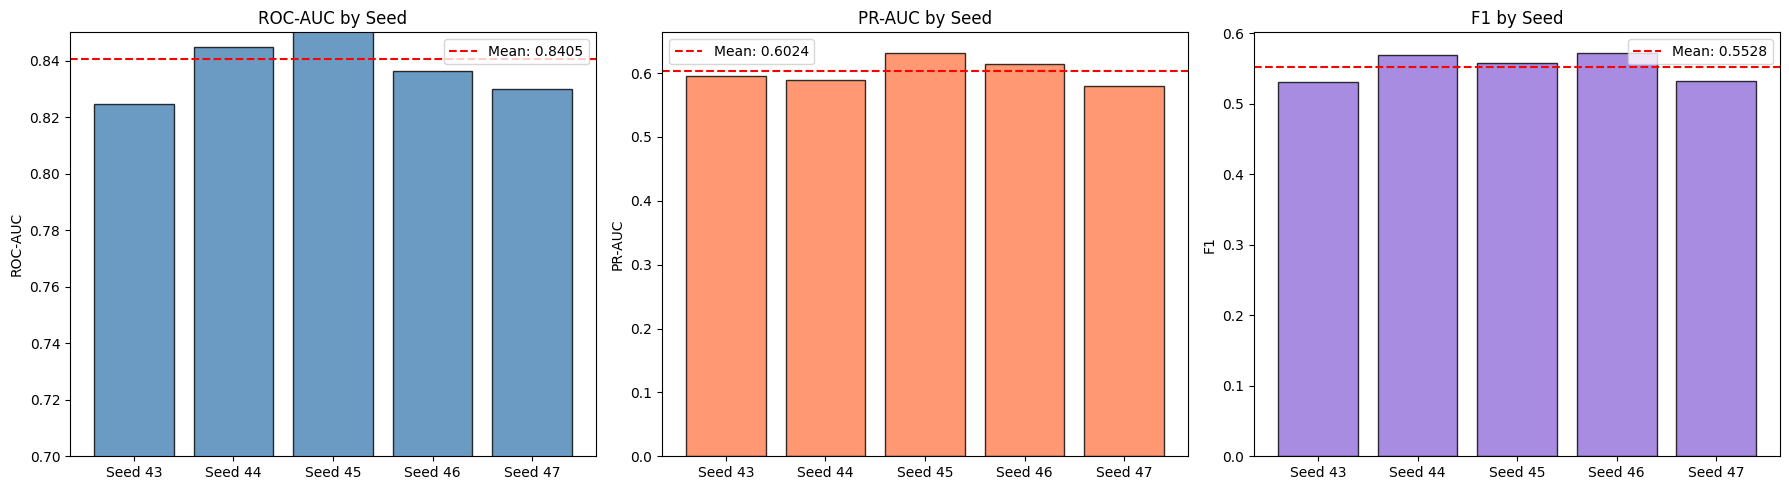

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ROC-AUC across seeds ──
ax = axes[0]
ax.bar(range(len(SEEDS)), results['roc_auc'], color='steelblue', edgecolor='black', alpha=0.8)
ax.axhline(np.mean(results['roc_auc']), color='red', linestyle='--', label=f'Mean: {np.mean(results["roc_auc"]):.4f}')
ax.set_xticks(range(len(SEEDS)))
ax.set_xticklabels([f'Seed {s}' for s in SEEDS])
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC by Seed')
ax.legend()
ax.set_ylim(0.7, 0.85)

# ── PR-AUC across seeds ──
ax = axes[1]
ax.bar(range(len(SEEDS)), results['pr_auc'], color='coral', edgecolor='black', alpha=0.8)
ax.axhline(np.mean(results['pr_auc']), color='red', linestyle='--', label=f'Mean: {np.mean(results["pr_auc"]):.4f}')
ax.set_xticks(range(len(SEEDS)))
ax.set_xticklabels([f'Seed {s}' for s in SEEDS])
ax.set_ylabel('PR-AUC')
ax.set_title('PR-AUC by Seed')
ax.legend()

# ── F1 across seeds ──
ax = axes[2]
ax.bar(range(len(SEEDS)), results['f1'], color='mediumpurple', edgecolor='black', alpha=0.8)
ax.axhline(np.mean(results['f1']), color='red', linestyle='--', label=f'Mean: {np.mean(results["f1"]):.4f}')
ax.set_xticks(range(len(SEEDS)))
ax.set_xticklabels([f'Seed {s}' for s in SEEDS])
ax.set_ylabel('F1')
ax.set_title('F1 by Seed')
ax.legend()

plt.tight_layout()
plt.show()

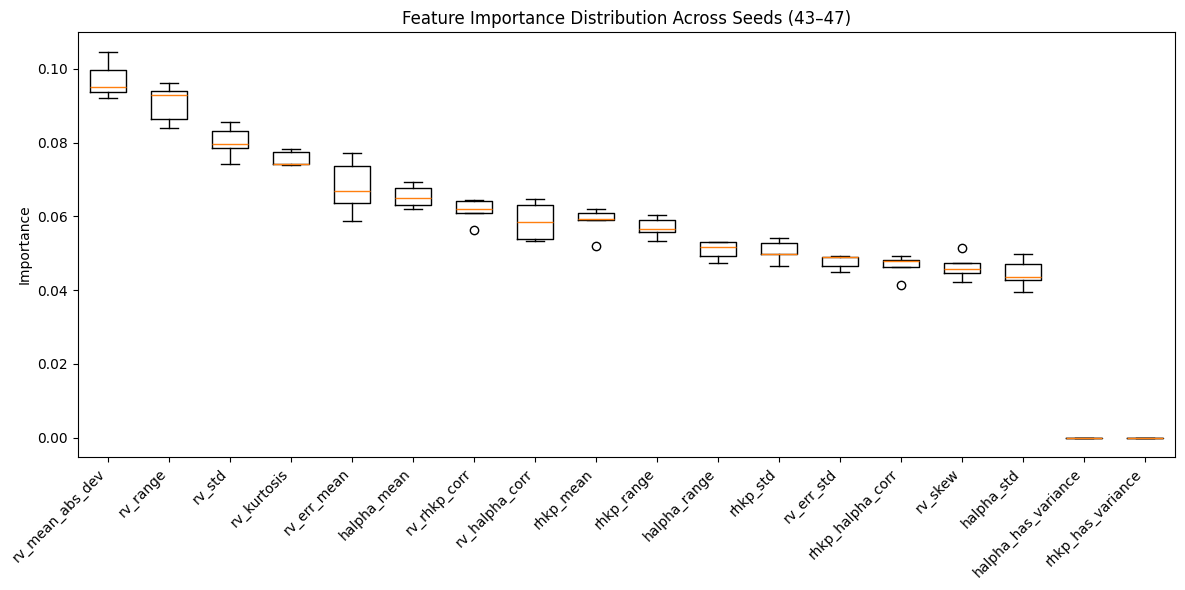

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
imp_data = [imp_df_sorted.loc[f, SEEDS].values for f in imp_df_sorted.index]
positions = range(len(imp_df_sorted))
ax.boxplot(imp_data, positions=positions, vert=True, widths=0.6)
ax.set_xticks(positions)
ax.set_xticklabels(imp_df_sorted.index, rotation=45, ha='right')
ax.set_ylabel('Importance')
ax.set_title(f'Feature Importance Distribution Across Seeds ({SEEDS[0]}–{SEEDS[-1]})')
plt.tight_layout()
plt.show()